# The Hamiltonian — from Classical Mechanics to Neural Networks

**One function that contains a system's entire future.**

This notebook walks through six self-contained demonstrations, each building on the last:

| # | Demo | Key idea |
|---|------|----------|
| 1 | Hamilton's equations vs Newton | Newton's laws fall out of one scalar function |
| 2 | Integrator shootout | Structure beats accuracy on long horizons |
| 3 | Liouville's theorem | Phase-space volume is frozen |
| 4 | Double pendulum | Chaotic behaviour and conserved rules coexist |
| 5 | Hamiltonian Neural Network | Conservation built into the architecture |
| 6 | Hamiltonian Monte Carlo | Same maths, zero physics |

**Requirements:** `numpy`, `matplotlib` (and optionally `scipy`).

## Setup

Import the standard scientific stack and configure a dark-theme colour palette that matches the companion HTML explainer.
`J2` is the 2×2 **symplectic matrix** — the single object that drives every demo:

$$\dot{x} = J\,\nabla H, \qquad J = \begin{pmatrix}0 & 1 \\ -1 & 0\end{pmatrix}$$

Because $J$ is antisymmetric, $\nabla H \cdot J\,\nabla H = 0$ for *any* $H$.
Energy conservation is a structural consequence of $J$, not a property of the specific system.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

rng = np.random.default_rng(0)

# The symplectic matrix — rotates any vector by 90°
J2 = np.array([[0.0, 1.0], [-1.0, 0.0]])

# Colour palette (matches the HTML explainer)
C = dict(bg="#0d1117", fg="#e6edf3", grid="#30363d",
         blue="#58a6ff", pink="#f778ba", green="#3fb950", amber="#d29922")

plt.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["bg"],
    "savefig.facecolor": C["bg"], "text.color": C["fg"],
    "axes.labelcolor": C["fg"], "xtick.color": C["fg"], "ytick.color": C["fg"],
    "axes.edgecolor": C["grid"], "grid.color": C["grid"],
    "figure.dpi": 120, "font.size": 9,
})

print("Setup complete. NumPy", np.__version__, "| Matplotlib", matplotlib.__version__)


Setup complete. NumPy 2.5.1 | Matplotlib 3.11.1


---
## Demo 1 — Hamilton's Equations Reproduce Newton

**What this cell does:** Define the total energy $H$ of a mass–spring system and compute its gradient numerically.
Then apply $\dot{x} = J\,\nabla H$ and check that the result exactly matches $F = ma$ from Newton's second law.

$$H(q,p) = \frac{p^2}{2m} + \frac{1}{2}kq^2$$

Hamilton's two equations of motion drop straight out of partial derivatives of $H$:

$$\dot{q} = \frac{\partial H}{\partial p} = \frac{p}{m}, \qquad \dot{p} = -\frac{\partial H}{\partial q} = -kq$$

$\dot{p} = -kq$ is Hooke's law. We never wrote down a force — we differentiated an energy function.

In [2]:
m, k = 1.3, 4.7  # mass and spring constant

def H_spring(x):
    """Total energy of a mass-spring system: H = p²/2m + kq²/2."""
    q, p = x
    return p**2 / (2*m) + 0.5*k*q**2

def grad(f, x, h=1e-6):
    """Central-difference gradient of scalar f at point x."""
    g = np.zeros_like(x)
    for i in range(len(x)):
        e = np.zeros_like(x); e[i] = h
        g[i] = (f(x + e) - f(x - e)) / (2*h)
    return g

# Evaluate at an arbitrary point (position=0.8, momentum=0.35)
x = np.array([0.8, 0.35])
qdot, pdot = J2 @ grad(H_spring, x)

print("From Hamilton's equations (J ∇H):")
print(f"  qdot = {qdot:+.6f}   (should equal p/m  = {x[1]/m:+.6f})")
print(f"  pdot = {pdot:+.6f}   (should equal -kq  = {-k*x[0]:+.6f})")
print()
print("✓ Newton's laws are a corollary of one scalar function.")


From Hamilton's equations (J ∇H):
  qdot = +0.269231   (should equal p/m  = +0.269231)
  pdot = -3.760000   (should equal -kq  = -3.760000)

✓ Newton's laws are a corollary of one scalar function.


---
## Demo 2 — Integrator Shootout: Euler vs Symplectic vs RK4

**What this cell does:** Implement four numerical integrators and run them all on the same harmonic oscillator ($H = \frac{q^2+p^2}{2}$) for 1 400 steps at step size $h = 0.22$.
Then plot the phase-space orbit and energy drift side by side.

The key insight: **accuracy and structural fidelity are different objectives.**

- **Explicit Euler** uses both $q$ and $p$ at time $t$ to update both — this is not area-preserving, and energy grows without bound.
- **Symplectic Euler** kicks $p$ first, then uses the *new* $p$ to drift $q$. One character changed; the map becomes area-preserving and energy error stays bounded forever.
- **Leapfrog (Velocity Verlet)** is second-order and time-reversible — the standard for molecular dynamics and planetary integration.
- **RK4** is the most accurate per step, yet still drifts on long horizons because it is *not* symplectic.

The shadow Hamiltonian explains why symplectic methods win: they conserve a slightly perturbed $\tilde{H} = H + h^2 H_2 + \cdots$ exactly, so the error oscillates in a bounded band rather than accumulating.

  Explicit Euler        energy error after 1400 steps: 5215430616190968751844732436480.00%
  Symplectic Euler      energy error after 1400 steps:     9.01%
  Leapfrog              energy error after 1400 steps:     0.31%
  RK4                   energy error after 1400 steps:     0.22%


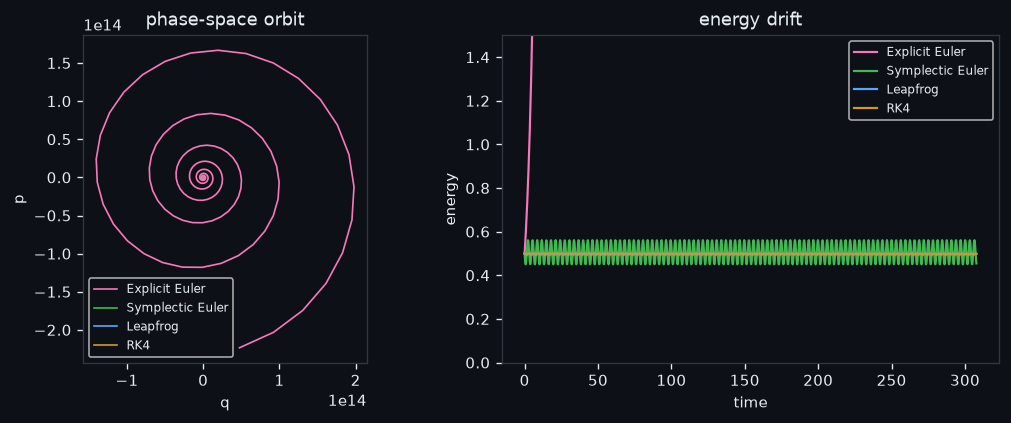

In [3]:
def euler(x, h, dV):
    q, p = x
    return np.array([q + h*p, p - h*dV(q)])          # both use OLD values

def symplectic_euler(x, h, dV):
    q, p = x
    p = p - h*dV(q)                                   # kick first …
    return np.array([q + h*p, p])                     # … drift with NEW p

def leapfrog(x, h, dV):
    q, p = x
    p = p - 0.5*h*dV(q)
    q = q + h*p
    p = p - 0.5*h*dV(q)
    return np.array([q, p])

def rk4(x, h, dV):
    f = lambda s: np.array([s[1], -dV(s[0])])
    k1 = f(x); k2 = f(x + h/2*k1); k3 = f(x + h/2*k2); k4 = f(x + h*k3)
    return x + h/6*(k1 + 2*k2 + 2*k3 + k4)

h, n_steps = 0.22, 1400
dV = lambda q: q              # dV/dq for H = (q² + p²)/2

methods = [
    ("Explicit Euler",    euler,            C["pink"]),
    ("Symplectic Euler",  symplectic_euler, C["green"]),
    ("Leapfrog",          leapfrog,         C["blue"]),
    ("RK4",               rk4,              C["amber"]),
]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.6))

for name, step, col in methods:
    x = np.array([1.0, 0.0])
    tr = np.zeros((n_steps, 2))
    for i in range(n_steps):
        tr[i] = x
        x = step(x, h, dV)
    e = 0.5 * (tr[:, 0]**2 + tr[:, 1]**2)
    a1.plot(tr[:, 0], tr[:, 1], color=col, lw=1, label=name)
    a2.plot(np.arange(n_steps)*h, e, color=col, lw=1.3, label=name)
    print(f"  {name:<20}  energy error after {n_steps} steps: {abs(e[-1]-e[0])/e[0]*100:8.2f}%")

a1.set_aspect("equal"); a1.set_xlabel("q"); a1.set_ylabel("p")
a1.set_title("phase-space orbit"); a1.legend(fontsize=7)
a2.set_xlabel("time"); a2.set_ylabel("energy"); a2.set_ylim(0, 1.5)
a2.set_title("energy drift"); a2.legend(fontsize=7)
fig.tight_layout()
plt.show()


---
## Demo 3 — Liouville's Theorem: Phase-Space Area Is Incompressible

**What this cell does:** Start with a closed ellipse of initial conditions (400 points on the boundary) and evolve every point forward under pendulum dynamics using RK4.
Compute the enclosed area via the shoelace formula at four time snapshots and print the drift.

**Liouville's theorem** says the divergence of the Hamiltonian vector field is exactly zero:

$$\nabla \cdot \dot{x} = \nabla \cdot (J\,\nabla H) = 0$$

The blob can stretch, shear, and fold into a filamentary mess — but its *area is frozen*.

Consequences you will see in the output:
- Hamiltonian systems **cannot** have attractors (attractors require volume contraction).
- Information is never destroyed, only stirred into unrecognisable shapes.
- Hamiltonian Monte Carlo gets a Jacobian determinant of exactly 1 for free, making the Metropolis acceptance ratio tractable.

In [ ]:
g = 9.81  # gravity

# Pendulum right-hand side: ds/dt = [p, -g sin(q)]
f_pend = lambda s: np.stack([s[:, 1], -g * np.sin(s[:, 0])], axis=1)

# Shoelace formula for polygon area
def area(c):
    x, y = c[:, 0], c[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

# Initial ellipse of 400 states
th = np.linspace(0, 2*np.pi, 400)
s = np.stack([0.15*np.cos(th) - 1.6, 0.55*np.sin(th) + 1.0], axis=1)
A0 = area(s)

h_rk = 0.004
fig, ax = plt.subplots(figsize=(5.5, 4))

for step in range(3001):
    if step % 750 == 0:
        ax.plot(np.append(s[:, 0], s[0, 0]),
                np.append(s[:, 1], s[0, 1]),
                lw=1.4, label=f"t={step*h_rk:.1f}s  area={area(s):.5f}")
        pct = abs(area(s) - A0) / A0 * 100
        print(f"  t = {step*h_rk:5.1f} s   area = {area(s):.6f}   (drift {pct:.4f}%)")
    k1 = f_pend(s)
    k2 = f_pend(s + h_rk/2*k1)
    k3 = f_pend(s + h_rk/2*k2)
    k4 = f_pend(s + h_rk*k3)
    s = s + h_rk/6 * (k1 + 2*k2 + 2*k3 + k4)

ax.set_xlabel("q (angle)"); ax.set_ylabel("p (angular momentum)")
ax.set_title("the blob deforms — the area does not"); ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


---
## Demo 4 — Double Pendulum: Chaos With Conserved Rules

**What this cell does:** Integrate two double pendulums that start just 1 nanoradian apart ($10^{-9}$ rad) and run for 200 000 RK4 steps at $h = 10^{-4}$ s.
Plot the separation between the two trajectories (left) and the energy drift of trajectory 1 (right).

The double pendulum is the canonical demonstration of **classical chaos**:
- The separation grows *exponentially* — this is what sensitivity to initial conditions means.
- The energy is pinned to roughly one part in $10^{10}$ — the Hamiltonian is intact.

**Chaos limits trajectory forecasting. It places no limit on conservation laws.**
A model that learns to conserve $H$ therefore stays meaningful long after a model that learned trajectories has become noise — this is the central argument for physics-structured machine learning.

In [ ]:
m1 = m2 = l1 = l2 = 1.0
g_dp = 9.81

def dp_rhs(y):
    """Right-hand side of the double-pendulum Hamilton equations."""
    t1, t2, p1, p2 = y
    d = t1 - t2
    den = l1 * l2 * (m1 + m2 * np.sin(d)**2)
    dt1 = (l2*p1 - l1*p2*np.cos(d)) / (l1*den)
    dt2 = (l1*(m1+m2)*p2 - l2*m2*p1*np.cos(d)) / (l2*m2*den)
    C1 = p1*p2*np.sin(d) / den
    C2 = (l2**2*m2*p1**2 + l1**2*(m1+m2)*p2**2
          - 2*l1*l2*m2*p1*p2*np.cos(d)) * np.sin(2*d) / (2*den**2)
    return np.array([dt1, dt2,
                     -(m1+m2)*g_dp*l1*np.sin(t1) - C1 + C2,
                     -m2*g_dp*l2*np.sin(t2) + C1 - C2])

def dp_energy(y):
    t1, t2, p1, p2 = y
    d = t1 - t2
    den = l1 * l2 * (m1 + m2 * np.sin(d)**2)
    dt1 = (l2*p1 - l1*p2*np.cos(d)) / (l1*den)
    dt2 = (l1*(m1+m2)*p2 - l2*m2*p1*np.cos(d)) / (l2*m2*den)
    T = (0.5*m1*(l1*dt1)**2
         + 0.5*m2*((l1*dt1)**2 + (l2*dt2)**2 + 2*l1*l2*dt1*dt2*np.cos(d)))
    V = -(m1+m2)*g_dp*l1*np.cos(t1) - m2*g_dp*l2*np.cos(t2)
    return T + V

h_dp, n_dp = 1e-4, 200_000
ys = [np.array([2.0, 2.2, 0.0, 0.0]),
      np.array([2.0, 2.2 + 1e-9, 0.0, 0.0])]   # differ by 1 nanoradian
E0 = dp_energy(ys[0])
seps, Es = [], []

for i in range(n_dp):
    for j in (0, 1):
        y = ys[j]
        k1 = dp_rhs(y); k2 = dp_rhs(y + h_dp/2*k1)
        k3 = dp_rhs(y + h_dp/2*k2); k4 = dp_rhs(y + h_dp*k3)
        ys[j] = y + h_dp/6*(k1 + 2*k2 + 2*k3 + k4)
    if i % 300 == 0:
        seps.append(np.linalg.norm(ys[0] - ys[1]))
        Es.append(dp_energy(ys[0]))

seps, Es = np.array(seps), np.array(Es)
t_dp = np.arange(len(seps)) * 300 * h_dp

print(f"  Initial separation : 1.0e-09 rad")
print(f"  Final separation   : {seps[-1]:.3e} rad  (grew {seps[-1]/1e-9:.1e}×) ← chaos")
print(f"  Energy drift       : {abs(Es[-1]-E0):.3e} J  (relative {abs(Es[-1]-E0)/abs(E0):.1e}) ← rules held")
print()
print("  Unpredictable and perfectly lawful, simultaneously.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4))
a1.semilogy(t_dp, seps, color=C["pink"])
a1.set_xlabel("time (s)"); a1.set_ylabel("separation (rad)")
a1.set_title("behaviour: diverges exponentially")
a2.plot(t_dp, Es - E0, color=C["green"])
a2.set_xlabel("time (s)"); a2.set_ylabel("energy drift (J)")
a2.set_title("rules: energy conserved")
fig.tight_layout()
plt.show()


---
## Demo 5 — Hamiltonian Neural Network (HNN), Built from Scratch

### Architecture

The network is a standard two-layer MLP that outputs a **single scalar** $H_\vartheta(q,p)$.
Dynamics are obtained by differentiating it:

$$\hat{\dot{q}} = \frac{\partial H_\vartheta}{\partial p}, \qquad \hat{\dot{p}} = -\frac{\partial H_\vartheta}{\partial q}$$

With $z = W_1 x + b_1$, $h = \tanh z$, $H = w_2^\top h$, the state-gradient is:

$$\nabla_x H = W_1^\top s, \qquad s_k = w_{2k}(1 - h_k^2)$$

Because the *output already contains a derivative*, the weight gradients require **second derivatives** — derived here entirely by hand (no autodiff):

$$u = J^\top \frac{\partial L}{\partial f}, \quad
  c_k = \sum_j u_j W_{1,kj}, \quad
  \delta z_k = c_k w_{2k}(-2h_k(1-h_k^2))$$

$$\frac{\partial L}{\partial W_1} = s^\top u + \delta z^\top x \quad \text{(two paths into } W_1\text{)}$$

The baseline network maps $(q,p) \to (\dot q, \dot p)$ directly — it can learn any vector field, including non-conservative ones.
The HNN *cannot* represent a non-conservative field by construction.

### Cell 5a — Helper functions: data, initialisation, training

**What this cell does:** Define the data-generation function (noisy mass-spring observations), weight initialisation, and the Adam optimiser loop.
These are shared by both the baseline and the HNN.

In [ ]:
def true_f(X):
    """Ground-truth vector field for the unit mass-spring: (q̇, ṗ) = (p, -q)."""
    return np.stack([X[:, 1], -X[:, 0]], axis=1)

def make_data(n=1500, noise=0.05):
    """Sample (state, derivative) pairs on an annulus with Gaussian noise."""
    r = rng.uniform(0.6, 2.1, n)
    th = rng.uniform(0, 2*np.pi, n)
    X = np.stack([r*np.cos(th), r*np.sin(th)], axis=1)
    return X, true_f(X) + rng.normal(0, noise, (n, 2))

def init_weights(hidden=200, n_out=1):
    """Xavier-style initialisation."""
    return dict(
        W1=rng.normal(0, 1.0, (hidden, 2)),
        b1=np.zeros(hidden),
        W2=rng.normal(0, np.sqrt(1/hidden), (n_out, hidden)),
        b2=np.zeros(n_out),
    )

def train(P, grad_fn, X, Y, steps=6000, lr=3e-3, batch=256):
    """Adam optimiser loop. Returns (updated_params, loss_history)."""
    m = {k: np.zeros_like(v) for k, v in P.items()}
    v = {k: np.zeros_like(v) for k, v in P.items()}
    hist = []
    for t in range(1, steps + 1):
        idx = rng.integers(0, len(X), batch)
        g, loss = grad_fn(P, X[idx], Y[idx])
        for k in P:
            m[k] = 0.9*m[k] + 0.1*g[k]
            v[k] = 0.999*v[k] + 0.001*g[k]**2
            P[k] -= lr * (m[k]/(1-0.9**t)) / (np.sqrt(v[k]/(1-0.999**t)) + 1e-8)
        hist.append(loss)
    return P, np.array(hist)

X_data, Y_data = make_data()
print(f"Dataset: {X_data.shape[0]} training points, input dim {X_data.shape[1]}, output dim {Y_data.shape[1]}")


### Cell 5b — Baseline network: direct vector-field regression

**What this cell does:** Define a standard MLP that maps $(q,p) \to (\dot{q}, \dot{p})$ directly.
This network has no structural constraint — it can represent any vector field, including ones that drain or inject energy.

In [ ]:
def baseline_forward(P, X):
    """Two-layer MLP: output is the 2-D vector field directly."""
    hidden = np.tanh(X @ P["W1"].T + P["b1"])
    return hidden @ P["W2"].T + P["b2"], hidden

def baseline_grads(P, X, Y):
    F, hidden = baseline_forward(P, X)
    dF = 2*(F - Y) / (len(X)*2)
    Dz = (dF @ P["W2"]) * (1 - hidden**2)
    grads = dict(
        W1=Dz.T @ X, b1=Dz.sum(0),
        W2=dF.T @ hidden, b2=dF.sum(0),
    )
    return grads, float(((F - Y)**2).mean())

print("Baseline network defined (output: 2-D vector field).")


### Cell 5c — HNN: scalar Hamiltonian with hand-derived second-derivative gradients

**What this cell does:** Define the HNN forward pass (which differentiates the learned scalar $H_\vartheta$ to produce the vector field) and its analytically-derived backward pass.

Two things are subtle:
1. `W1` receives gradient along **two paths** — once through $\nabla_x H = W_1^\top s$, and once through $z$. Missing either causes silent underperformance.
2. The output bias `b2` has **zero gradient** — only derivatives of $H$ are observable, so the absolute energy offset is unidentifiable.

In [ ]:
def hnn_forward(P, X):
    """
    Forward pass: output is J ∇_x H, the symplectic gradient of the learned scalar H.
    Returns (vector_field, cache) where cache holds intermediate values for backprop.
    """
    Z = X @ P["W1"].T + P["b1"]
    Hh = np.tanh(Z)
    Hp = 1 - Hh**2              # tanh'(z) = 1 - tanh²(z)
    w2 = P["W2"][0]
    S = Hp * w2                 # s_k = w2_k * tanh'(z_k)
    G = S @ P["W1"]             # ∇_x H = W1ᵀ s
    return G @ J2.T, dict(Hh=Hh, Hp=Hp, S=S, w2=w2)

def hnn_scalar(P, X):
    """Return the learned H value itself (for plotting contour levels)."""
    return (np.tanh(X @ P["W1"].T + P["b1"]) @ P["W2"].T)[:, 0]

def hnn_grads(P, X, Y):
    """
    Backward pass with hand-derived second-derivative terms.
    The second-derivative term arises because the output already contains ∂H/∂x.
    """
    F, c = hnn_forward(P, X)
    dF = 2*(F - Y) / (len(X)*2)
    U  = dF @ J2                                         # dL / d(∇H)
    Cc = U @ P["W1"].T                                   # dL / ds
    Dz = Cc * c["w2"] * (-2*c["Hh"]*c["Hp"])            # ← second-derivative term
    grads = dict(
        W1 = c["S"].T @ U + Dz.T @ X,   # two paths into W1
        b1 = Dz.sum(0),
        W2 = (Cc * c["Hp"]).sum(0)[None, :],
        b2 = np.zeros(1),                # unobservable — always zero
    )
    return grads, float(((F - Y)**2).mean())

print("HNN defined (output: J ∇H, scalar Hamiltonian learned internally).")


### Cell 5d — Gradient check

**What this cell does:** Verify the hand-derived HNN gradients against finite differences.
This is a sanity check before training — if the analytic gradients are wrong, training silently underperforms and this test catches it.

In [ ]:
def check_gradients(n_hidden=6, n_points=20, eps=1e-6):
    """Compare analytic gradients to central finite differences."""
    P_test = init_weights(hidden=n_hidden, n_out=1)
    X_test, Y_test = make_data(n_points)
    g_analytic, _ = hnn_grads(P_test, X_test, Y_test)
    worst = 0.0
    for key in ("W1", "b1", "W2"):
        flat  = P_test[key].ravel()
        g_flat = g_analytic[key].ravel()
        for i in rng.integers(0, len(flat), min(8, len(flat))):
            orig = flat[i]
            flat[i] = orig + eps
            lp = ((hnn_forward(P_test, X_test)[0] - Y_test)**2).mean()
            flat[i] = orig - eps
            lm = ((hnn_forward(P_test, X_test)[0] - Y_test)**2).mean()
            flat[i] = orig
            fd = (lp - lm) / (2*eps)
            worst = max(worst, abs(fd - g_flat[i]))
    return worst

err = check_gradients()
print(f"Gradient check — max |analytic − finite-diff|: {err:.2e}")
assert err < 1e-5, "Gradient mismatch — check the backward pass!"
print("✓ Gradients correct.")


### Cell 5e — Train both models

**What this cell does:** Train the baseline and the HNN for 6 000 Adam steps each on the same noisy mass-spring dataset.
Both models will converge to essentially the same training loss — the difference is invisible here and only appears on a long rollout.

In [ ]:
print("Training baseline network …")
P_base, loss_base = train(init_weights(hidden=200, n_out=2), baseline_grads, X_data, Y_data)
print(f"  Final loss (last 500 steps avg): {loss_base[-500:].mean():.5f}")

print("Training HNN …")
P_hnn, loss_hnn = train(init_weights(hidden=200, n_out=1), hnn_grads, X_data, Y_data)
print(f"  Final loss (last 500 steps avg): {loss_hnn[-500:].mean():.5f}")

print()
print("Both models converged to essentially the same training loss.")
print("The structural difference is invisible in-distribution.")


### Cell 5f — Compare training loss curves

**What this cell does:** Plot the loss histories of the baseline and the HNN side by side.
This confirms that the HNN architectural constraint did not hurt fitting quality — both curves reach the same floor.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(loss_base, color=C["pink"],  lw=1, alpha=0.9, label="Baseline")
ax.semilogy(loss_hnn,  color=C["green"], lw=1, alpha=0.9, label="HNN")
ax.set_xlabel("Training step"); ax.set_ylabel("MSE loss (log scale)")
ax.set_title("Training loss — both models reach the same floor")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### Cell 5g — Long-horizon rollout comparison

**What this cell does:** Roll both models forward for 1 400 steps with an RK4 integrator starting from $(q,p) = (1.6,\ 0)$.
Then plot the phase-space orbit, the predicted vs true trajectory, and the energy over time.

This is where the structural difference becomes catastrophic:
- The baseline's energy **leaks away** — it slowly spirals into the origin.
- The HNN's energy error is bounded by the RK4 integrator's tolerance, not by the model.
- Both had identical training loss. The failure is *invisible in-distribution* and only surfaces on long horizons.

In [ ]:
def rollout(model_fn, x0, steps=1400, h=0.05):
    """RK4 rollout starting from x0 using the learned vector field."""
    x = np.array(x0, float)[None, :]
    out = np.zeros((steps, 2))
    for i in range(steps):
        out[i] = x[0]
        k1 = model_fn(x); k2 = model_fn(x + h/2*k1)
        k3 = model_fn(x + h/2*k2); k4 = model_fn(x + h*k3)
        x = x + h/6*(k1 + 2*k2 + 2*k3 + k4)
    return out

x0 = [1.6, 0.0]
R_true = rollout(true_f, x0)
R_base = rollout(lambda x: baseline_forward(P_base, x)[0], x0)
R_hnn  = rollout(lambda x: hnn_forward(P_hnn, x)[0], x0)

E = lambda R: 0.5*(R[:, 0]**2 + R[:, 1]**2)
print(f"Energy change after long rollout:")
print(f"  Baseline: {abs(E(R_base)[-1]-E(R_base)[0])/E(R_base)[0]*100:5.1f}% lost")
print(f"  HNN     : {abs(E(R_hnn)[-1] -E(R_hnn)[0]) /E(R_hnn)[0] *100:5.2f}% (RK4 integrator error)")

t_roll = np.arange(len(R_true)) * 0.05
fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))

ax[0].plot(R_true[:, 0], R_true[:, 1], color=C["fg"],   lw=3, alpha=0.35, label="true")
ax[0].plot(R_base[:, 0], R_base[:, 1], color=C["pink"],  lw=1, label="baseline")
ax[0].set_title("Baseline rollout"); ax[0].set_aspect("equal")
ax[0].set_xlabel("q"); ax[0].set_ylabel("p"); ax[0].legend(fontsize=7)

ax[1].plot(R_true[:, 0], R_true[:, 1], color=C["fg"],   lw=3, alpha=0.35, label="true")
ax[1].plot(R_hnn[:, 0],  R_hnn[:, 1],  color=C["green"], lw=1, label="HNN")
ax[1].set_title("HNN rollout"); ax[1].set_aspect("equal")
ax[1].set_xlabel("q"); ax[1].set_ylabel("p"); ax[1].legend(fontsize=7)

ax[2].plot(t_roll, E(R_true), color=C["fg"],   lw=2.5, alpha=0.4, label="true")
ax[2].plot(t_roll, E(R_base), color=C["pink"],  lw=1,   label="baseline")
ax[2].plot(t_roll, E(R_hnn),  color=C["green"], lw=1,   label="HNN")
ax[2].set_title("Energy over time"); ax[2].set_xlabel("time"); ax[2].set_ylabel("H")
ax[2].legend(fontsize=7)

fig.tight_layout()
plt.show()


### Cell 5h — Learned Hamiltonian contours

**What this cell does:** Plot the level sets of the *learned scalar* $H_\vartheta(q,p)$ over a grid.
The HNN was only ever shown derivative observations — it never saw an energy value directly.
Yet it recovers the correct circular level sets of $H = \frac{q^2+p^2}{2}$ because those are the only scalar functions consistent with the observed $\dot{x} = J\,\nabla H$ structure.

In [ ]:
q_grid = np.linspace(-2.5, 2.5, 120)
p_grid = np.linspace(-2.5, 2.5, 120)
QQ, PP = np.meshgrid(q_grid, p_grid)
XY = np.stack([QQ.ravel(), PP.ravel()], axis=1)

H_learned = hnn_scalar(P_hnn, XY).reshape(QQ.shape)
H_true    = 0.5 * (QQ**2 + PP**2)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))

cf1 = a1.contourf(QQ, PP, H_true,    levels=20, cmap="viridis")
a1.set_title("True H = (q² + p²)/2"); a1.set_xlabel("q"); a1.set_ylabel("p")
fig.colorbar(cf1, ax=a1)

cf2 = a2.contourf(QQ, PP, H_learned, levels=20, cmap="viridis")
a2.set_title("Learned H_θ (from derivative observations only)")
a2.set_xlabel("q"); a2.set_ylabel("p")
fig.colorbar(cf2, ax=a2)

fig.tight_layout()
plt.show()
print("The learned contours are circular — correct up to an additive constant")
print("(the absolute energy offset is unidentifiable from derivative data alone).")


---
## Demo 6 — Hamiltonian Monte Carlo: Same Maths, No Physics

**What this cell does:** Sample from a highly correlated 2-D Gaussian (correlation $\rho = 0.93$) using HMC in 40 lines.
No physical system exists here — $U(q) = -\log \pi(q)$ plays the role of potential energy, and $p$ is a fictitious momentum drawn fresh each step.

HMC works by inventing a Hamiltonian:

$$H(q,p) = \underbrace{-\log \pi(q)}_{\text{potential}} + \underbrace{\tfrac{1}{2}p^\top M^{-1}p}_{\text{kinetic}}$$

Leapfrog integration keeps the trajectory near the energy shell, so proposals travel *far* across the distribution while maintaining near-unit acceptance rates.
Volume preservation (Liouville) ensures the Metropolis ratio involves no Jacobian — it equals exactly 1, making the correction tractable.

This is why HMC dominates probabilistic programming (Stan, PyMC, NumPyro): it is exponentially more efficient than random-walk MCMC in high dimensions.

In [ ]:
# Target: correlated 2-D Gaussian with ρ = 0.93
Sigma = np.array([[1.0, 0.93], [0.93, 1.0]])
Prec  = np.linalg.inv(Sigma)
U     = lambda q: 0.5 * q @ Prec @ q     # potential energy = -log π(q) + const
dU    = lambda q: Prec @ q               # gradient of potential

def hmc_step(q, eps=0.18, L=22):
    """One HMC proposal: draw momentum, leapfrog L steps, Metropolis accept/reject."""
    p    = rng.normal(size=2)
    H0   = U(q) + 0.5*p @ p
    qn, pn = q.copy(), p.copy()
    pn  -= 0.5*eps*dU(qn)           # half kick
    for _ in range(L):
        qn += eps*pn                # drift
        pn -= eps*dU(qn)            # kick
    pn  += 0.5*eps*dU(qn)           # undo trailing half kick
    pn   = -pn                      # momentum flip for reversibility
    H1   = U(qn) + 0.5*pn @ pn
    accept = np.log(rng.uniform()) < H0 - H1
    return (qn, True) if accept else (q, False)

q_curr   = np.zeros(2)
samples  = []
n_accept = 0

for _ in range(4000):
    q_curr, accepted = hmc_step(q_curr)
    n_accept += accepted
    samples.append(q_curr.copy())

S = np.array(samples[500:])   # discard burn-in

print(f"  Acceptance rate    : {n_accept/4000:.3f}  (target ~0.65–0.80)")
print(f"  Target correlation : {Sigma[0,1]:.3f}")
print(f"  Sampled correlation: {np.corrcoef(S.T)[0,1]:.3f}")

fig, ax = plt.subplots(figsize=(4.2, 4))
ax.plot(S[:, 0], S[:, 1], ".", ms=1.8, color=C["blue"], alpha=0.5)
ax.set_title("HMC samples from correlated Gaussian")
ax.set_xlabel("q₁"); ax.set_ylabel("q₂"); ax.set_aspect("equal")
fig.tight_layout()
plt.show()


---
## Summary

All six demos rest on one equation:

$$\boxed{\dot{x} = J\,\nabla H, \qquad J = \begin{pmatrix}0 & 1 \\ -1 & 0\end{pmatrix}}$$

| Demo | What it showed |
|------|---------------|
| 1 | $J\,\nabla H$ reproduces Newton — no forces needed |
| 2 | Symplectic integrators conserve a *shadow* $H$ exactly; non-symplectic ones drift |
| 3 | Phase-space volume is frozen (Liouville) — no attractors possible |
| 4 | Chaos = exponential trajectory divergence, coexisting with exact conservation |
| 5 | Encoding $J\,\nabla H$ into the architecture makes conservation *unrepresentable* to violate |
| 6 | Replace $-\log\pi$ with the potential and the same mechanics gives you a state-of-the-art MCMC sampler |

### Further reading
- Greydanus, Dzamba & Yosinski — *Hamiltonian Neural Networks* (NeurIPS 2019) `arXiv:1906.01563`
- Cranmer et al. — *Lagrangian Neural Networks* (2020) `arXiv:2003.04630`
- Betancourt — *A Conceptual Introduction to Hamiltonian Monte Carlo* `arXiv:1701.02434`
- Hairer, Lubich & Wanner — *Geometric Numerical Integration* (symplectic integrators & shadow Hamiltonians)
